In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [83]:
df=pd.read_csv('/content/car.csv')

In [84]:
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [85]:
print(df.tail())

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
296     city  2016           9.50           11.6       33988    Diesel   
297     brio  2015           4.00            5.9       60000    Petrol   
298     city  2009           3.35           11.0       87934    Petrol   
299     city  2017          11.50           12.5        9000    Diesel   
300     brio  2016           5.30            5.9        5464    Petrol   

    Seller_Type Transmission  Owner  
296      Dealer       Manual      0  
297      Dealer       Manual      0  
298      Dealer       Manual      0  
299      Dealer       Manual      0  
300      Dealer       Manual      0  


In [86]:
print(df.describe())#to read all statistical terms

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [87]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [88]:
print(df.isnull().sum())#no need to drop as no null values are present

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [89]:
df.shape

(301, 9)

In [90]:
print(df.duplicated().sum())

2


In [91]:
df=df.drop_duplicates()

In [92]:
df.shape

(299, 9)

**Features(Independent)&Target(Dependent) Variables**

In [93]:
x = df[['Year', 'Fuel_Type', 'Present_Price', 'Kms_Driven', 'Seller_Type', 'Transmission']]
y = df['Selling_Price']

# Perform one-hot encoding on categorical features
x = pd.get_dummies(x, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

**Train test split**

In [94]:
#Split the data into training and testing data sets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [95]:
#Create a linear regression model
model=LinearRegression()
#Train the model
model.fit(x_train,y_train)

LinearRegression()

In [96]:
#Make predictions on the test set
Y_pred=model.predict(x_test)
Y_pred

array([ 7.50043163,  7.81104111,  1.39768641,  7.02450491, 11.16047067,
        4.54274802,  8.48533905,  1.72657222,  8.83514448, -0.93076493,
       10.36489038, -0.90512352,  0.78692512,  1.55004622,  4.33534603,
        5.03737903,  1.31163219,  1.87888311, 21.55899556,  0.89080359,
        0.95766314,  1.84793663,  5.57803558,  0.32257524,  6.28960954,
        7.82239771,  8.69061953,  1.19923758,  4.86508228,  4.91753376,
        3.24063459,  4.84118416,  6.29830129,  2.79799837,  2.90103707,
        6.98878381,  1.29395527, -5.1824736 ,  1.38985309, 10.39543392,
        7.09129742,  9.05494392,  1.65523848,  4.04243706,  1.00464913,
       -2.0618152 ,  8.13392992,  4.38900981,  5.65803497, -0.56306977,
        0.70221307,  0.25259877,  8.29539531,  9.46053879,  7.29650266,
        6.25462523,  3.73803669,  3.43350117,  9.57383045,  9.163373  ])

In [97]:
#Calculate Mean Squared Error
mse=mean_squared_error(y_test,Y_pred)
print("Mean Squared Error:",mse)#print(f"Mean Squared Error:{mse}")

Mean Squared Error: 5.938718957803074


In [98]:
#Calculate R-squared value
r2=r2_score(y_test,Y_pred)#Strength of the straight line
print("R-squared value:",r2)#print(f"R-squared value:{r2}")

R-squared value: 0.7695782975939076


**Plotting the linear regression model**

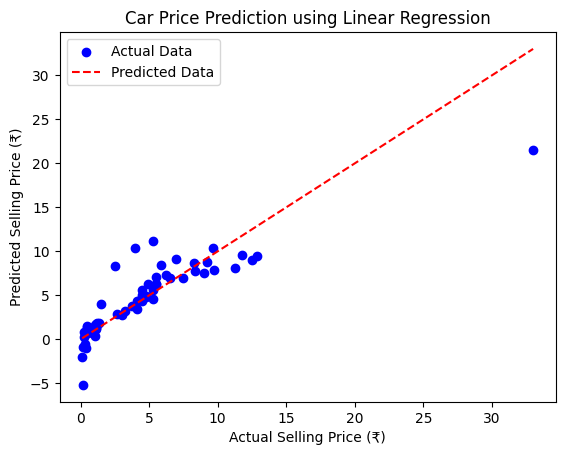

In [99]:
plt.scatter(y_test, Y_pred, color='blue', label='Actual Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Predicted Data')
plt.xlabel('Actual Selling Price (₹)')
plt.ylabel('Predicted Selling Price (₹)')
plt.title('Car Price Prediction using Linear Regression')
plt.legend()
plt.show()

In [100]:
import joblib

# Save the trained model to a file
joblib.dump(model, 'car_price_prediction_model.pkl')

print("Model saved successfully as 'car_price_prediction_model.pkl'")

Model saved successfully as 'car_price_prediction_model.pkl'
